In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('datasets.csv')

df['Declaration Date'] = pd.to_datetime(df['Declaration Date'], format='%m/%d/%Y')

df = df.rename(columns={'Disaster Type': 'Incident type'})

df['year'] = df['Declaration Date'].dt.year
df['month'] = df['Declaration Date'].dt.month

print(df['Declaration Date'].isna().sum(), "missing dates found.")
yearly_counts = df.groupby('year').size()
type_trends = df.groupby(['year', 'Incident type']).size().unstack(fill_value=0)



0 missing dates found.


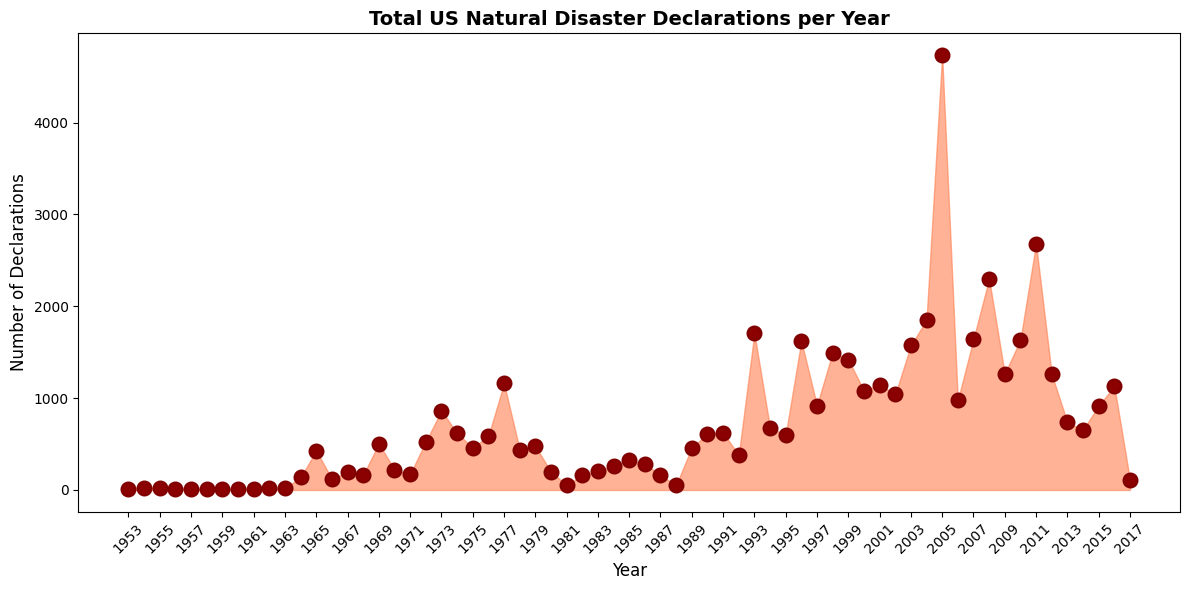

In [26]:
# Visualizing total declarations using area chart with gradient colors
plt.figure(figsize=(12, 6))
plt.fill_between(yearly_counts.index, yearly_counts.values, alpha=0.6, color='coral')
plt.scatter(yearly_counts.index, yearly_counts.values, s=100, color='darkred', zorder=5, edgecolors='maroon', linewidth=1.5)
plt.xticks(range(int(yearly_counts.index.min()), int(yearly_counts.index.max()) + 1, 2), rotation=45)
plt.title('Total US Natural Disaster Declarations per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Declarations', fontsize=12)
plt.tight_layout()
plt.show()

## Key Observations from the Chart:

**What the chart shows:**
- Displays the number of disaster declarations in the US from 1953 to 2017 (65 years of data)
- Shows a general upward trend over time

**Main findings:**

**1. Is there an increasing trend?**
- Yes! Disasters increased from the 1960s, decreased in the 1980s, then increased again from the 1990s onwards

**2. What about the big spike in 2005?**
- There's a huge spike in 2005, mostly caused by many hurricanes and floods that year
- This is the highest point on the entire chart

**3. Why did it drop in 2006?**
- After the spike in 2005, there was a sharp drop in 2006
- This is because 2005 had unusually high disasters that didn't repeat in 2006

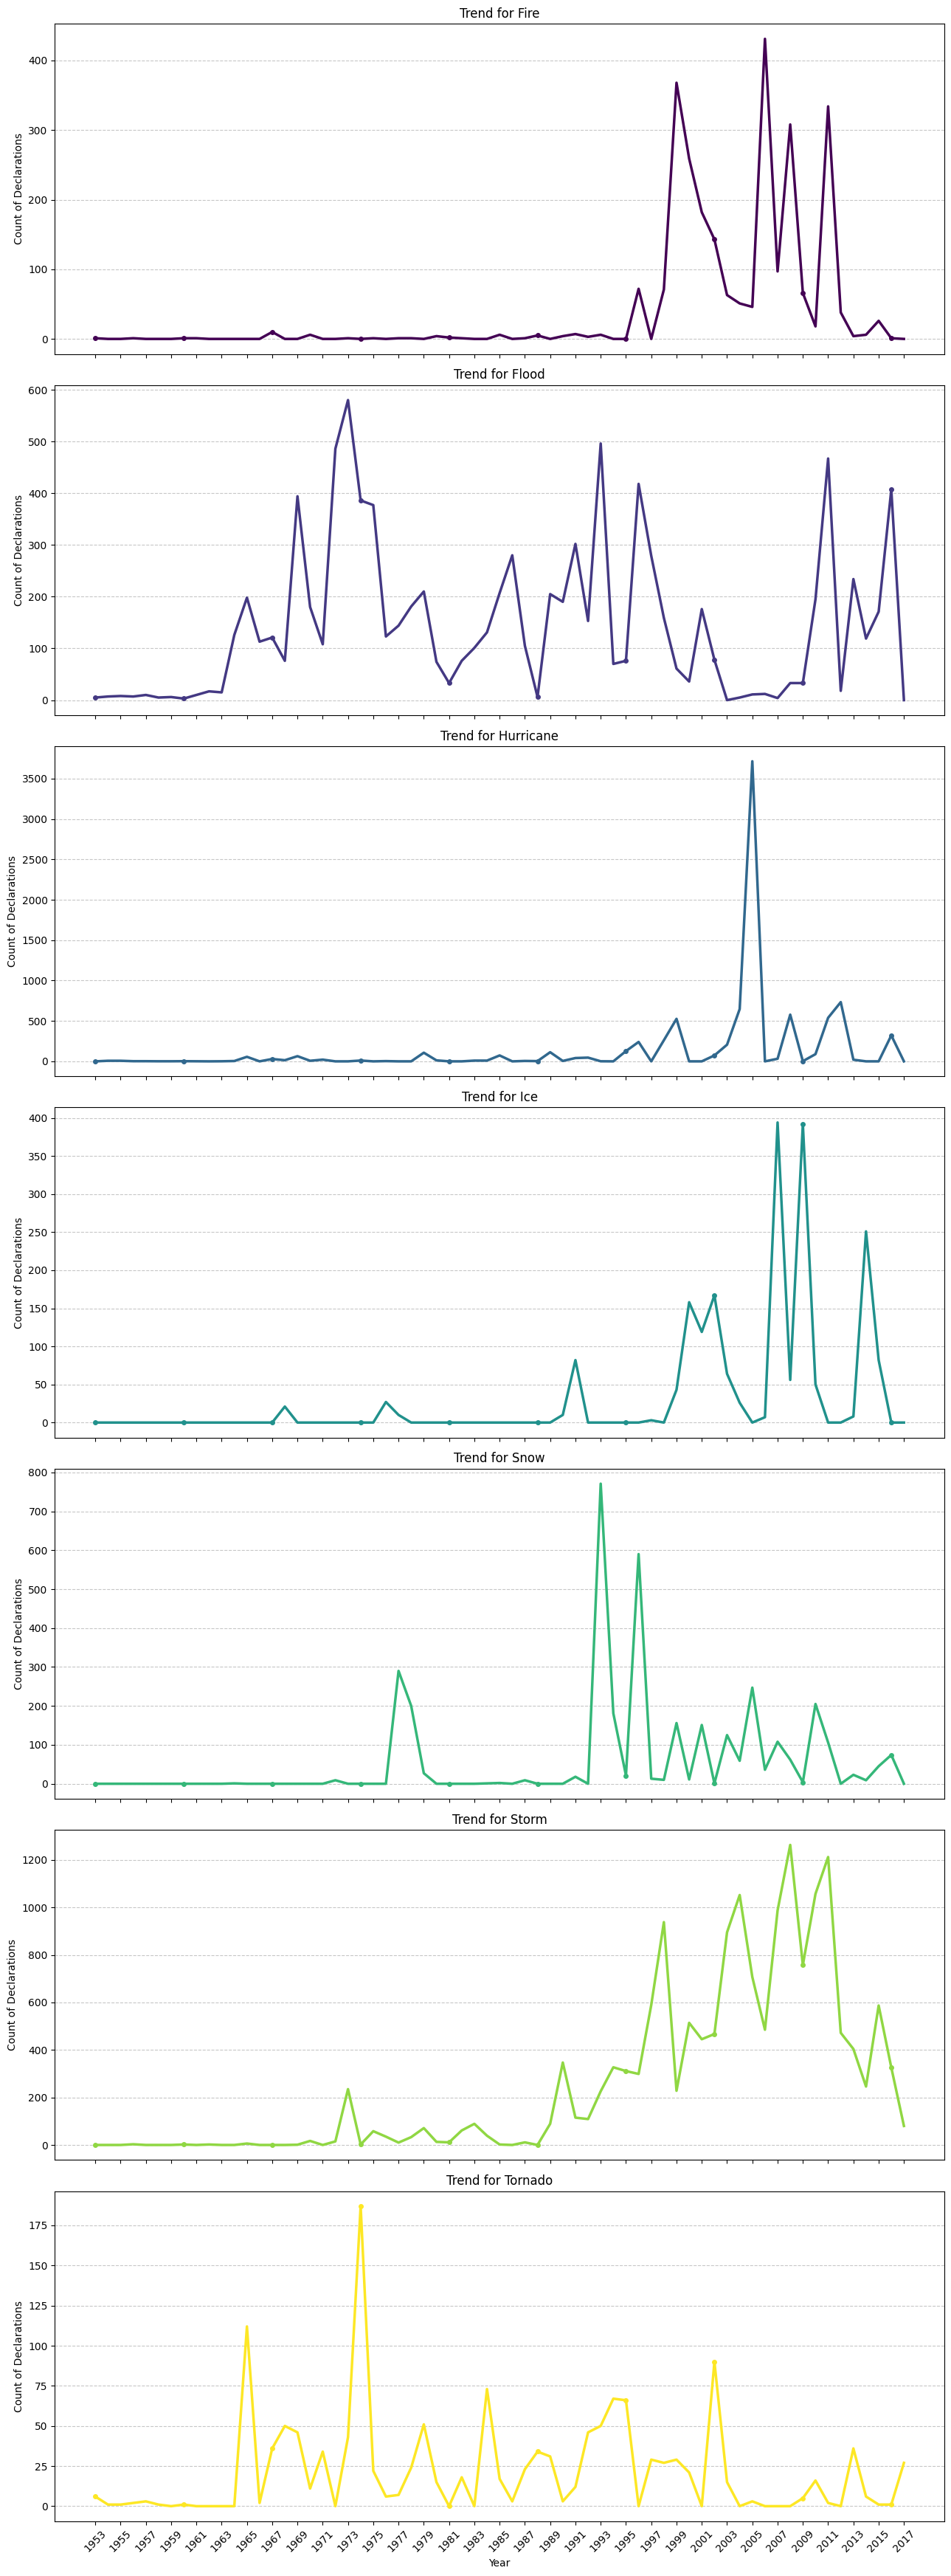

In [27]:
#visualizing trends for the top 7 incident types over time using subplots
import matplotlib.cm as cm

type_counts = df['Incident type'].value_counts().head(7).index
type_trends = df[df['Incident type'].isin(type_counts)].groupby(['year', 'Incident type']).size().unstack(fill_value=0)

colors = cm.viridis(np.linspace(0, 1, 7))

fig, axes = plt.subplots(7, 1, figsize=(13, 35), sharex=True)

for i, column in enumerate(type_trends.columns):
    axes[i].plot(type_trends.index, 
                 type_trends[column], 
                 label=column, 
                 color=colors[i], 
                 linewidth=2.5,
                 marker='o', 
                 markersize=4, 
                 markevery=7)
    axes[i].set_title(f'Trend for {column}')
    axes[i].set_ylabel('Count of Declarations')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.xlabel('Year')
plt.xticks(range(int(type_trends.index.min()), int(type_trends.index.max()) + 1, 2), rotation=45)
plt.tight_layout()
plt.show()

## Understanding the 7 Disaster Types (1954-2017):

**What the chart shows:**
- Tracks the top 7 most common types of disasters over 63 years
- Each line represents one type of disaster

**Key findings:**

**1. Which disasters happen most often?**
- Hurricanes and Storms are the most common disasters
- Floods are also very frequent and happen regularly
- These three disasters affect large areas at once and happen in almost every season in the US

**2. Which disasters are getting worse?**
- Hurricanes and Storms are increasing the fastest
- Their numbers doubled starting in the late 1980s and 1990s
- They've had even bigger surges in recent years

**3. Which disasters are getting better?**
- Snow-related incidents had a spike in the 1990s but have been declining since
- Tornadoes remain the least common of the top 7 disasters throughout the entire period

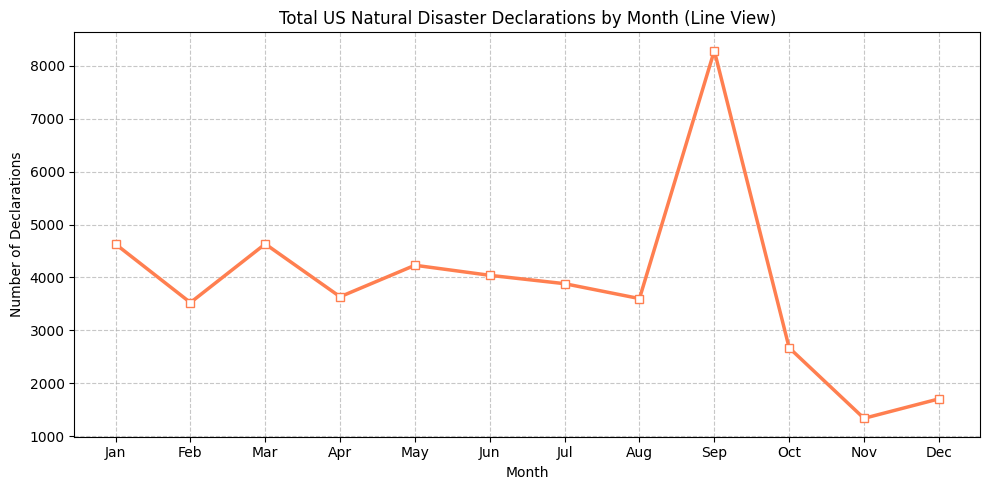

In [28]:

#visualizing the total number of declarations by month
plt.figure(figsize=(10, 5))
monthly_counts = df.groupby('month').size()
plt.plot(monthly_counts.index, monthly_counts.values, color='coral', linewidth=2.5, marker='s', markersize=6, markerfacecolor='white', markeredgecolor='coral')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Total US Natural Disaster Declarations by Month (Line View)')
plt.xlabel('Month')
plt.ylabel('Number of Declarations')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Disasters by Month - Seasonal Patterns (1953-2017):

**What the chart shows:**
- Displays the total number of disasters that occur in each month
- Covers 64 years of data from 1953 to 2017
- Shows a clear seasonal pattern

**When do disasters happen most?**

**1. The Three Peak Months:**
- **September (Highest)**: Has the most disasters - this is when hurricanes hit the US coast the hardest
- **January & March (Second Highest)**: Both have similar high numbers caused by winter storms and spring flooding

**2. Why does this pattern happen?**
- **Winter (Dec-Jan)**: Snow, blizzards, and ice storms occur frequently
- **Spring (Mar-May)**: Snow melts cause floods, especially in March
- **Summer (Jun-Aug)**: Droughts, wildfires, and storms become common
- **Fall (Sep)**: Hurricane season peaks, causing massive damage across many states

**3. Is there a pattern?**
- Yes! Disasters follow the seasons and repeat every year
- September always has the biggest spike due to hurricanes
- January and March see consistent peaks from winter and spring weather
- The pattern repeats predictably because of how weather changes throughout the year

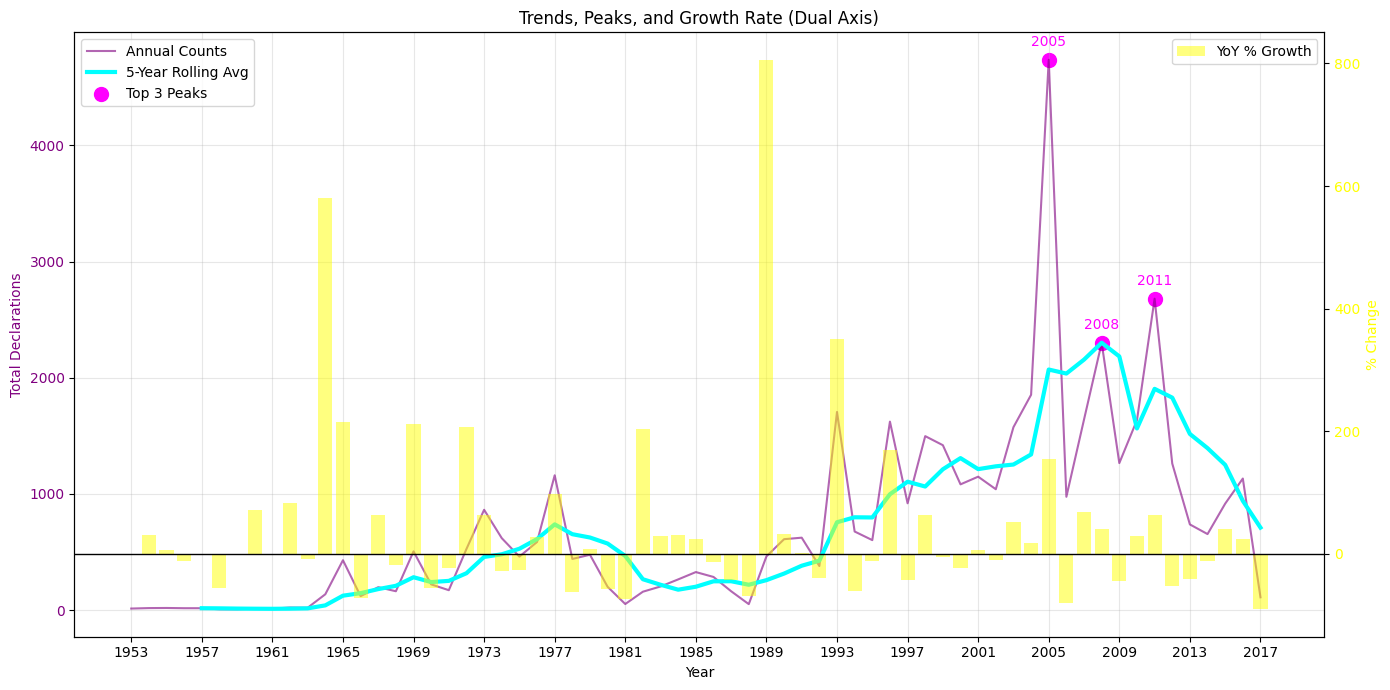

Maximum Growth Year: 1989 (805.88%)
Top 3 Disaster Peaks: 
year
2005    4736
2011    2680
2008    2300
dtype: int64


In [29]:
rolling_avg = yearly_counts.rolling(window=5).mean()

# Calculate the year-over-year percentage change (growth rate)
growth_rate = yearly_counts.pct_change() * 100

# Find the top 3 peak years with the highest disaster counts
peaks = yearly_counts.nlargest(3)

# Plot with dual y-axes: left for counts, right for growth rate
fig, ax1 = plt.subplots(figsize=(14, 7))

# Left axis: Annual counts and rolling average
ax1.plot(yearly_counts.index, yearly_counts.values, label='Annual Counts', color='purple', alpha=0.6)
ax1.plot(rolling_avg.index, rolling_avg.values, label='5-Year Rolling Avg', color='cyan', linewidth=3)
ax1.scatter(peaks.index, peaks.values, color='magenta', s=100, label='Top 3 Peaks')

# Add labels to the peak points
for year, value in peaks.items():
    ax1.annotate(f'{year}', (year, value), textcoords="offset points", xytext=(0,10), ha='center', color='magenta')

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Declarations', color='purple')
ax1.tick_params(axis='y', labelcolor='purple')
ax1.legend(loc='upper left')

# Right axis: Growth rate as bars
ax2 = ax1.twinx()
ax2.bar(growth_rate.index, growth_rate.values, color='yellow', alpha=0.5, label='YoY % Growth', width=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_ylabel('% Change', color='yellow')
ax2.tick_params(axis='y', labelcolor='yellow')
ax2.legend(loc='upper right')

plt.title('Trends, Peaks, and Growth Rate (Dual Axis)')
plt.xticks(range(int(yearly_counts.index.min()), int(yearly_counts.index.max()) + 1, 4), rotation=45)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(f"Maximum Growth Year: {growth_rate.idxmax()} ({growth_rate.max():.2f}%)")
print(f"Top 3 Disaster Peaks: \n{peaks}")

## What You See in the Diagram - Explained:

**The Layout:**
This is a **dual-axis chart** - one chart with TWO different measurement scales:
- **Left side (Purple Axis)**: Measures total disaster count (0 to 4000+)
- **Right side (Yellow Axis)**: Measures year-over-year percentage change (-200% to +900%)

**Reading the Purple Lines (Left Side) - The Main Story:**

1. **Purple wiggly line = Annual Counts**
   - Shows raw disasters each year
   - Goes up and down unpredictably
   - Has big spikes in 2005, 2008, 2011

2. **Cyan/Blue thick line = 5-Year Rolling Average**
   - Smooths out the yearly noise
   - Reveals the TRUE long-term trend
   - Clearly shows: disasters increasing since 1990s
   - This is the most important line to follow

3. **Magenta dots with year labels = The 3 Worst Years**
   - 2005 (highest point) = 4,736 disasters
   - 2011 (second bump) = 2,680 disasters
   - 2008 (third bump) = 2,300 disasters
   - They stand out above the trend line

**Reading the Yellow Bars (Right Side) - The Volatility:**

- **Yellow bars = Year-to-year percentage change**
- **Tall bars going UP** = huge jump from previous year
- **Short bars or going DOWN** = slight change or decrease
- **The tallest bar (around 1989)** = Over 800% increase (disaster count nearly tripled!)
- **Black line at zero** = reference for no change

**How to Interpret:**
- The cyan line shows disasters are getting worse overall (upward trend)
- The yellow bars show some specific years experienced extreme jumps
- Major spikes (tall yellow bars) often align with the magenta peak markers
- This tells us: "Normal years vary, but since the 1990s, disasters are steadily increasing"